#The Enthusiast: Bir, Katie, Tariere & Brad

* The Moving Average Convergence Divergence (MACD)

* For all teams: ARIMA

# Part I-
Task: ARIMA = AR (Classic Autoregressive) + MA (Moving Average)

MACD = 12-Period EMA − 26-Period EMA


# Data Extracting

In [ ]:
# Imports & Setup
import os
import json
import math
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple
import yfinance as yf
from google.colab import userdata
from pandas.tseries.offsets import BDay

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

ALPHAVANTAGE_API_KEY = userdata.get('ALPHAVANTAGE_API_KEY')

In [ ]:
def get_date_range_by_business_days(start_date_str: str, num_periods: int) -> tuple[str, str]:
    """
    Given a start date string and a number of business days, returns a tuple
    of two date strings (start_date, end_date) where end_date is num_periods
    business days from start_date. If num_periods is negative, the dates are
    swapped to ensure the first date is before the second.

    Args:
        start_date_str: The starting date as a string in 'YYYY-MM-DD' format.
        num_periods: The number of business days to add (can be negative).

    Returns:
        A tuple of two date strings (date1, date2) where date1 <= date2.
    """
    start_date = pd.to_datetime(start_date_str)

    if num_periods >= 0:
        end_date = start_date + BDay(num_periods)
        date1_str = start_date.strftime('%Y-%m-%d')
        date2_str = end_date.strftime('%Y-%m-%d')
    else:
        end_date = start_date + BDay(num_periods)
        date1_str = end_date.strftime('%Y-%m-%d')
        date2_str = start_date.strftime('%Y-%m-%d')

    return (date1_str, date2_str)

print(get_date_range_by_business_days('2021-01-01', 500))
print(get_date_range_by_business_days('2021-01-15', -5))

('2021-01-01', '2022-12-02')
('2021-01-08', '2021-01-15')


In [ ]:
def get_stock_data(symbol: str, start_date: str = None, end_date: str = None) -> pd.DataFrame:
    """
    Downloads Yahoo Finance historical data for a single stock symbol.

    Args:
        symbol: The stock ticker symbol.
        start_date: Optional start date string in 'YYYY-MM-DD' format.
        end_date: Optional end date string in 'YYYY-MM-DD' format.

    Returns:
        A pandas DataFrame with Date as the index and columns for open, high,
        low, close, adjusted_close, and volume, all in lowercase.
    """
    # Download data for the single symbol
    df = yf.download(symbol, start=start_date, end=end_date, auto_adjust=False, progress=False)

    # Ensure Date is the index (it usually is by default with yfinance)
    if 'Date' in df.columns:
        df = df.set_index('Date')

    # Handle potential MultiIndex columns by flattening before lowercasing
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns.values] # Flatten MultiIndex to string

    # Convert column names to lowercase
    df.columns = df.columns.str.lower()

    # Rename 'adj close' to 'adjusted_close' if it exists
    if 'adj close' in df.columns:
        df = df.rename(columns={'adj close': 'adjusted_close'})

    # Select and reorder relevant columns
    # Ensure all expected columns exist before selecting
    required_cols = ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
    for col in required_cols:
        if col not in df.columns:
            # Handle cases where a column might be missing (e.g., for very new stocks)
            # For this context, we might raise an error or log a warning
            print(f"Warning: Column '{col}' not found for symbol {symbol}. Skipping.")
            # Or, add the column with NaNs
            # df[col] = np.nan

    # Filter for required columns that are actually present
    cols_to_select = [col for col in required_cols if col in df.columns]
    df = df[cols_to_select]


    return df

In [ ]:
# Setting up the stock symbol to use and the periods to consider
tickers = ["NVDA", "FSLR", "MSFT", "TSLA", "SPY"] # Possible stocks to analyze
SYMBOL = tickers[3]
PERIODS = 500
START_DATE = '2025-06-01' # Changed start date

# Optional: compact vs full (full returns all history, compact ~100 days)
OUTPUT_SIZE = "full"  # "full" or "compact"

# Basic validation
if ALPHAVANTAGE_API_KEY == "REPLACE_WITH_YOUR_KEY":
    print("Please set ALPHAVANTAGE_API_KEY (above) to your real Alpha Vantage key.")
else:
    print("API key detected.")
print(f"Using symbol: {SYMBOL}")

API key detected.
Using symbol: TSLA


In [ ]:
def fetch_alpha_vantage_daily_adjusted(symbol: str, apikey: str, output_size: str = "compact", start_date: str = None, end_date: str = None) -> pd.DataFrame:
    """
    Fetch TIME_SERIES_DAILY_ADJUSTED from Alpha Vantage.
    Returns a DataFrame with columns: ['open','high','low','close','adjusted_close','volume','dividend_amount','split_coefficient']
    indexed by pandas datetime in ascending order, filtered by start and end dates if provided.
    """
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY_ADJUSTED",
        "symbol": symbol,
        "apikey": apikey,
        "outputsize": output_size
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP error {r.status_code}: {r.text}")
    data = r.json()

    if "Error Message" in data:
        raise ValueError(f"API returned error: {data['Error Message']}")
    if "Time Series (Daily)" not in data:
        raise ValueError(f"Unexpected payload (rate limit or invalid key?): {json.dumps(data)[:500]}")


    ts = data["Time Series (Daily)"]
    df = pd.DataFrame.from_dict(ts, orient="index", dtype=float)
    df.index = pd.to_datetime(df.index)
    df = df.rename(columns={
        "1. open": "open",
        "2. high": "high",
        "3. low": "low",
        "4. close": "close",
        "5. adjusted close": "adjusted_close",
        "6. volume": "volume",
        "7. dividend amount": "dividend_amount",
        "8. split coefficient": "split_coefficient"
    })
    df = df.sort_index()  # ascending

    # Filter by date range if start_date or end_date are provided
    if start_date:
        start_datetime = pd.to_datetime(start_date)
        df = df[df.index >= start_datetime]
    if end_date:
        end_datetime = pd.to_datetime(end_date)
        df = df[df.index <= end_datetime]

    return df

try:
    df = fetch_alpha_vantage_daily_adjusted(SYMBOL,
                                            ALPHAVANTAGE_API_KEY,
                                            output_size=OUTPUT_SIZE,
                                            start_date=START_DATE,
                                            end_date='2025-09-01') # Changed end date
except:
    # You found a stock that requires a premium access to the Alpha Vantage API. Rollback to the Yahoo Finance API
    df = get_stock_data(SYMBOL, start_date=START_DATE, end_date='2025-09-01') # Changed end date

print(df.head(3))
print(df.tail(3))

                  open        high         low       close  adjusted_close  \
Date                                                                         
2025-06-02  343.500000  348.019989  333.329987  342.690002      342.690002   
2025-06-03  346.600006  355.399994  343.040009  344.269989      344.269989   
2025-06-04  345.100006  345.600006  327.329987  332.049988      332.049988   

              volume  
Date                  
2025-06-02  81873800  
2025-06-03  99324500  
2025-06-04  98912100  
                  open        high         low       close  adjusted_close  \
Date                                                                         
2025-08-27  351.940002  355.390015  349.160004  349.600006      349.600006   
2025-08-28  350.910004  353.549988  340.260010  345.980011      345.980011   
2025-08-29  347.230011  348.750000  331.700012  333.869995      333.869995   

              volume  
Date                  
2025-08-27  65519000  
2025-08-28  67903200  
2025-08-29 

#Exploratory Statistics

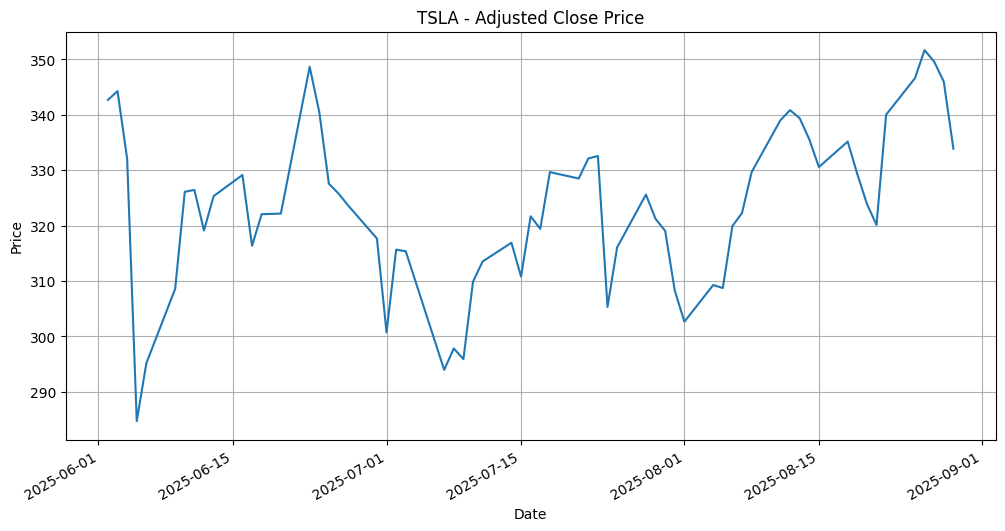

In [ ]:
# Line plot of adjusted close price
plt.figure(figsize=(12, 6))
df['adjusted_close'].plot(title=f'{SYMBOL} - Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

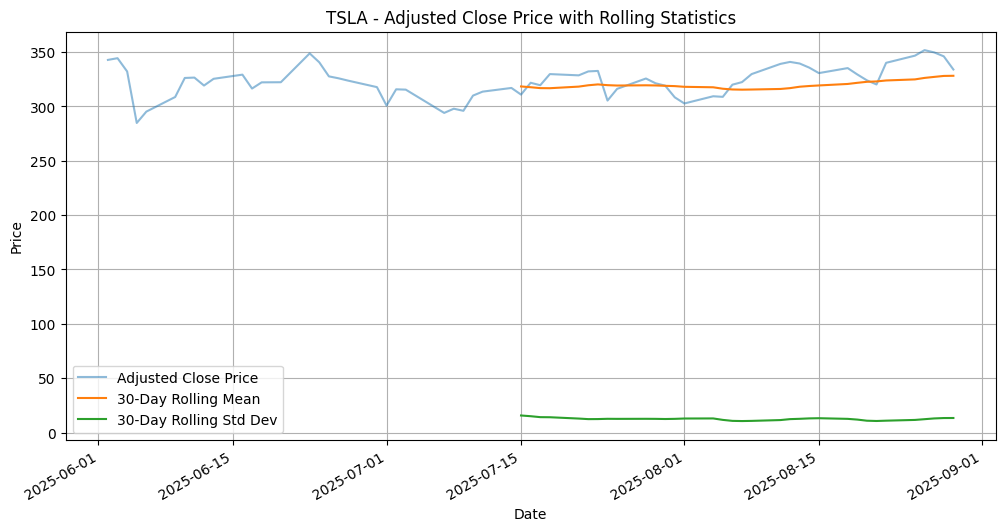

In [ ]:
# Rolling statistics (e.g., 30-day rolling mean and standard deviation)
rolling_mean = df['adjusted_close'].rolling(window=30).mean()
rolling_std = df['adjusted_close'].rolling(window=30).std()

plt.figure(figsize=(12, 6))
df['adjusted_close'].plot(label='Adjusted Close Price', alpha=0.5)
rolling_mean.plot(label='30-Day Rolling Mean')
rolling_std.plot(label='30-Day Rolling Std Dev')
plt.title(f'{SYMBOL} - Adjusted Close Price with Rolling Statistics')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Summary statistics
print("\nSummary Statistics for Adjusted Close Price:")
display(df['adjusted_close'].describe())


Summary Statistics for Adjusted Close Price:


,adjusted_close
count,63.000000
mean,323.200316
std,14.917970
min,284.700012
25%,315.500000
50%,323.630005
75%,332.334991
max,351.670013


# Identifying Time Series Components

In [ ]:
# Calculate the log of the adjusted close price
df['log_price'] = np.log(df['adjusted_close'])

# Display the first few rows to confirm the new column
display(df.head())

,open,high,low,close,adjusted_close,volume,log_price
Date,,,,,,,
2025-06-02,343.500000,348.019989,333.329987,342.690002,342.690002,81873800,5.836826
2025-06-03,346.600006,355.399994,343.040009,344.269989,344.269989,99324500,5.841426
2025-06-04,345.100006,345.600006,327.329987,332.049988,332.049988,98912100,5.805286
2025-06-05,322.489990,324.549988,273.209991,284.700012,284.700012,287499800,5.651436
2025-06-06,298.829987,305.500000,291.140015,295.140015,295.140015,164747700,5.687450


In [ ]:
#
def adf_kpss_report(series: pd.Series, name: str = "series") -> Tuple[float, float]:
    """Run ADF & KPSS and print a compact summary. Returns (adf_p, kpss_p)."""
    series = series.dropna()
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression="c", nlags="auto")
    print(f"\n=== Stationarity Report for {name} ===")
    print(f"ADF:  stat={adf_stat: .4f}, p={adf_p: .4f} | crit={adf_crit}")
    print(f"KPSS: stat={kpss_stat: .4f}, p={kpss_p: .4f} | crit={kpss_crit}")
    return adf_p, kpss_p

# Determine d by iteratively differencing the log-price
y = df["log_price"].copy()
d = 0
max_d = 2

while d <= max_d:
    adf_p, kpss_p = adf_kpss_report(y, name=f"log_price differenced {d} times")
    adf_ok = adf_p < 0.05     # reject unit root
    kpss_ok = kpss_p > 0.05   # fail to reject stationarity

    if adf_ok and kpss_ok:
        print(f"\nSelected d = {d} (series appears stationary)." )
        break
    else:
        d += 1
        if d > max_d:
            print("\nReached maximum differencing (d=2). Proceeding with d=2 even if borderline.")
            d = max_d
            break
        y = y.diff()  # difference once and test again

# Keep a reference to the stationary (d-differenced) series for ACF/PACF
y_stationary = df["log_price"].diff(d).dropna() if d > 0 else df["log_price"].dropna()


=== Stationarity Report for log_price differenced 0 times ===
ADF:  stat=-3.3700, p= 0.0120 | crit={'1%': np.float64(-3.540522678829176), '5%': np.float64(-2.9094272025108254), '10%': np.float64(-2.5923136524453696)}
KPSS: stat= 0.3569, p= 0.0957 | crit={'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Selected d = 0 (series appears stationary).


<Figure size 1200x400 with 0 Axes>

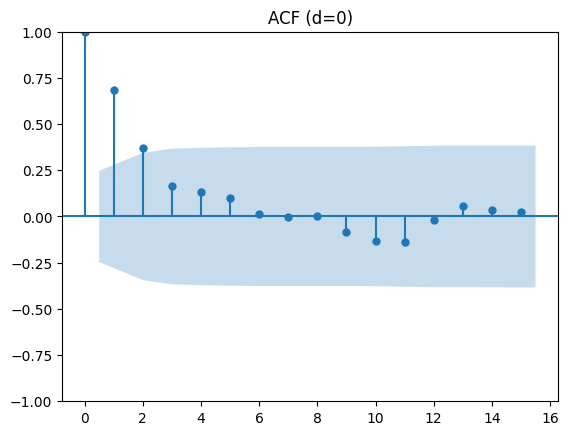

<Figure size 1200x400 with 0 Axes>

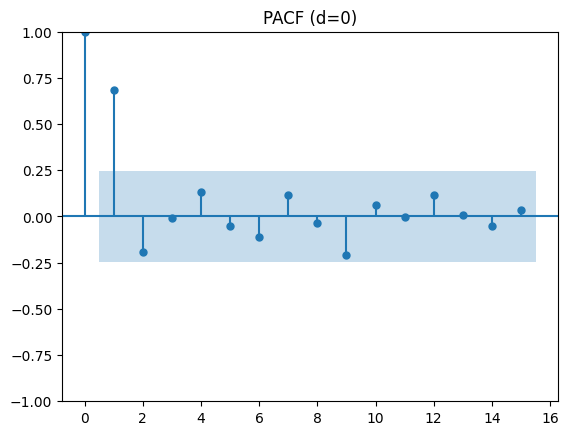

In [ ]:
# Plot ACF & PACF for the differenced log-price
lags = min(60, len(y_stationary) // 4)

fig = plt.figure(figsize=(12, 4))
plot_acf(y_stationary, lags=lags, title=f"ACF (d={d})")
plt.show()

fig = plt.figure(figsize=(12, 4))
plot_pacf(y_stationary, lags=lags, title=f"PACF (d={d})", method="ywm")
plt.show()

# Dealing with Non-Stationary and Modeling

In [ ]:
import warnings

# Store the original warnings filter
original_filters = warnings.filters[:]

# Temporarily change the filter for ConvergenceWarning within this cell's execution
warnings.filterwarnings("always", "DeprecationWarning")


def fit_arima_grid(y_original: pd.Series, d: int, p_max: int = 5, q_max: int = 5,
                   enforce_stationarity: bool = False, enforce_invertibility: bool = False) -> pd.DataFrame:
    """
    Fit ARIMA(p,d,q) for p in [0..p_max], q in [0..q_max] with fixed d.
    Returns a DataFrame with rows: (p,d,q,AIC,BIC) sorted by AIC.
    """
    results = []

    # Ensure the series has no NaNs and a DatetimeIndex
    y_clean = y_original.dropna().copy()
    if not isinstance(y_clean.index, pd.DatetimeIndex):
         y_clean.index = pd.to_datetime(y_clean.index)

    # Attempt to set frequency to 'B' (Business daily) - important for forecasting
    # If setting frequency fails, statsmodels might still handle it with freq='B' parameter
    try:
        y_clean = y_clean.asfreq('B')
        print("Successfully set frequency to 'B'.")
    except ValueError:
        print("Could not set frequency to 'B'. Proceeding without explicit frequency on index.")
        # If asfreq fails, y_clean retains its original index (hopefully DatetimeIndex)


    for p in range(p_max + 1):
        for q in range(q_max + 1):
            order = (p, d, q)
            try:
                # Fit ARIMA on the cleaned series without specifying freq in the constructor
                model = ARIMA(y_clean, order=order, enforce_stationarity=enforce_stationarity,
                              enforce_invertibility=enforce_invertibility)
                fitted = model.fit() # Removed maxiter here
                results.append({
                    "p": p, "d": d, "q": q,
                    "aic": fitted.aic,
                    "bic": fitted.bic
                })
                print(f"Fitted ARIMA{order}: AIC={fitted.aic:.2f}, BIC={fitted.bic:.2f}")
            except DeprecationWarning as w:
                 continue
            except Exception as e:
                print(f"ARIMA{order} failed: {e}")
                continue

    # Restore original warnings filter after the loop
    warnings.filters = original_filters

    if not results:
        print("No ARIMA models were successfully fit.")
        return pd.DataFrame() # Return empty DataFrame if no models fit

    res_df = pd.DataFrame(results).sort_values(by="aic", ascending=True).reset_index(drop=True)
    return res_df

grid_results = fit_arima_grid(df["log_price"], d=d, p_max=5, q_max=5)
display(grid_results.head(10))

Successfully set frequency to 'B'.
Fitted ARIMA(0, 0, 0): AIC=-202.07, BIC=-197.75
Fitted ARIMA(0, 0, 1): AIC=-226.84, BIC=-220.41
Fitted ARIMA(0, 0, 2): AIC=-237.81, BIC=-229.30
Fitted ARIMA(0, 0, 3): AIC=-239.09, BIC=-228.53
Fitted ARIMA(0, 0, 4): AIC=-238.15, BIC=-225.59


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitted ARIMA(0, 0, 5): AIC=-234.41, BIC=-219.87
Fitted ARIMA(1, 0, 0): AIC=-241.99, BIC=-235.52
Fitted ARIMA(1, 0, 1): AIC=-237.08, BIC=-228.51
Fitted ARIMA(1, 0, 2): AIC=-236.03, BIC=-225.40
Fitted ARIMA(1, 0, 3): AIC=-246.60, BIC=-233.93


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitted ARIMA(1, 0, 4): AIC=-239.78, BIC=-225.12


...

Fitted ARIMA(5, 0, 3): AIC=-220.70, BIC=-199.76


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitted ARIMA(5, 0, 4): AIC=-221.63, BIC=-198.59
Fitted ARIMA(5, 0, 5): AIC=-226.06, BIC=-201.13


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,aic,bic
0,1,0,3,-246.595815,-233.930571
1,4,0,0,-246.146792,-233.481549
2,2,0,3,-245.206083,-230.429966
3,4,0,1,-244.256971,-229.480854
4,3,0,3,-243.299705,-226.412714
5,1,0,0,-241.992737,-235.516087
6,4,0,2,-240.230423,-223.343433
7,1,0,4,-239.783800,-225.123388
8,0,0,3,-239.085928,-228.531558
9,5,0,0,-238.952102,-224.291690


In [ ]:
if len(grid_results) == 0:
    raise RuntimeError("No ARIMA models were successfully fit. Adjust the grid or check data.")

best_aic_row = grid_results.iloc[0]
best_bic_row = grid_results.sort_values("bic").iloc[0]

order_aic = (int(best_aic_row.p), int(best_aic_row.d), int(best_aic_row.q))
order_bic = (int(best_bic_row.p), int(best_bic_row.d), int(best_bic_row.q))

print(f"Best by AIC: ARIMA{order_aic} (AIC={best_aic_row.aic:.2f}, BIC={best_aic_row.bic:.2f})")
print(f"Best by BIC: ARIMA{order_bic} (AIC={best_bic_row.aic:.2f}, BIC={best_bic_row.bic:.2f})")

model_aic = ARIMA(df["log_price"], order=order_aic).fit()
model_bic = ARIMA(df["log_price"], order=order_bic).fit()

print("=== Summary (AIC winner) ===")
print(model_aic.summary())

print("=== Summary (BIC winner) ===")
print(model_bic.summary())

Best by AIC: ARIMA(1, 0, 3) (AIC=-246.60, BIC=-233.93)
Best by BIC: ARIMA(1, 0, 0) (AIC=-241.99, BIC=-235.52)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


=== Summary (AIC winner) ===
                               SARIMAX Results                                
Dep. Variable:              log_price   No. Observations:                   63
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 126.264
Date:                Tue, 25 Nov 2025   AIC                           -240.528
Time:                        22:24:58   BIC                           -227.670
Sample:                             0   HQIC                          -235.471
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7786      0.015    383.015      0.000       5.749       5.808
ar.L1          0.6451      1.068      0.604      0.546      -1.448       2.738
ma.L1          0.1575  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(1, 0, 3) (AIC winner): Ljung–Box test p-values
    lb_pvalue
10   0.944461
20   0.776654
30   0.913919


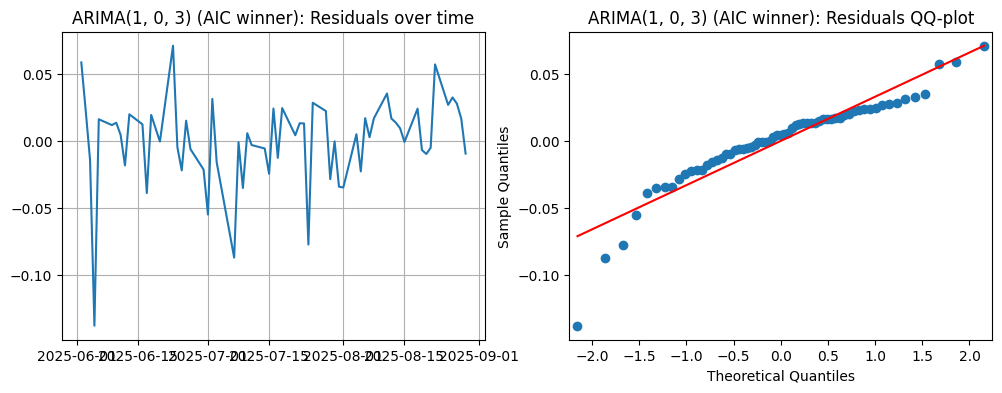

ARIMA(1, 0, 0) (BIC winner): Ljung–Box test p-values
    lb_pvalue
10   0.768545
20   0.686187
30   0.820952


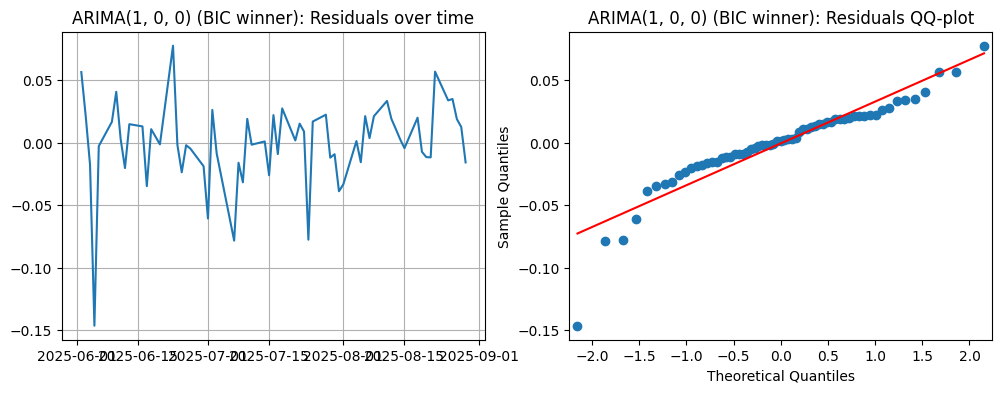

In [ ]:
def residual_diagnostics(fitted_model, title_prefix="Model"):
    resid = fitted_model.resid.dropna()

    # Ljung-Box test for autocorrelation at multiple lags
    lags = [10, 20, 30]
    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    print(f"{title_prefix}: Ljung–Box test p-values")
    print(lb[["lb_pvalue"]])

    # Residual plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(resid)
    ax[0].set_title(f"{title_prefix}: Residuals over time"); ax[0].grid(True)

    # QQ plot
    from statsmodels.graphics.gofplots import qqplot
    qqplot(resid, line='s', ax=ax[1])
    ax[1].set_title(f"{title_prefix}: Residuals QQ-plot")
    plt.show()

residual_diagnostics(model_aic, title_prefix=f"ARIMA{order_aic} (AIC winner)")
residual_diagnostics(model_bic, title_prefix=f"ARIMA{order_bic} (BIC winner)")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


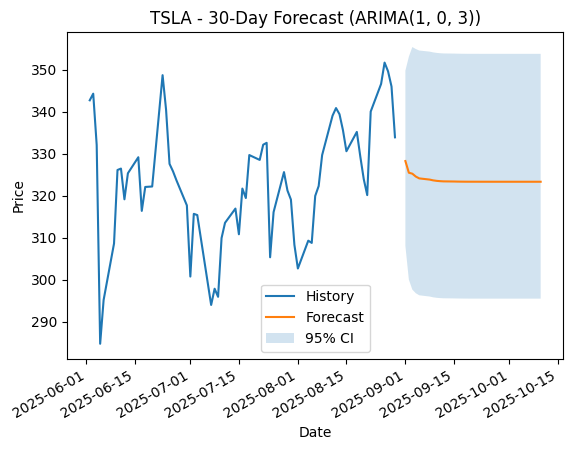

In [ ]:
steps_ahead = 30
fcast = model_aic.get_forecast(steps=steps_ahead)

# Forecasts are on the log-price scale; convert to price
f_mean = fcast.predicted_mean
f_ci = fcast.conf_int(alpha=0.05)

# --- Ensure the forecast index is DatetimeIndex (avoid PeriodIndex converter conflicts) ---
# Generate a correct future index starting after the last date of historical data
last_hist_date = df.index[-1]
future_idx = pd.bdate_range(start=last_hist_date, periods=steps_ahead + 1)[1:] # Start after last_hist_date, exclude the first date

# Build price-scale series with the correct future DatetimeIndex using the values
f_mean_price = pd.Series(np.exp(f_mean.values), index=future_idx, name="Forecast")
f_ci_price = pd.DataFrame(np.exp(f_ci.values), index=future_idx, columns=f_ci.columns)

# Also ensure history uses DatetimeIndex
hist = df["adjusted_close"].iloc[-200:].copy()
hist.index = pd.to_datetime(hist.index)

# Plot without converter warnings
ax = hist.plot(label="History", grid=True, title=f"{SYMBOL} - 30-Day Forecast (ARIMA{order_aic})")
f_mean_price.plot(ax=ax, label="Forecast")
ax.fill_between(future_idx, f_ci_price.iloc[:, 0].values, f_ci_price.iloc[:, 1].values, alpha=0.2, label="95% CI")
ax.set_xlabel("Date")
ax.set_ylabel("Price"); ax.legend()
plt.show()

In [ ]:
last_diff = df["log_price"].diff().iloc[-1]
phi = model_aic.params.get("ar.L1", 0.0)
theta = model_aic.params.get("ma.L1", 0.0)

print("Last Δlog-price:", float(last_diff))
print("AR(1) φ:", float(phi))
print("MA(1) θ:", float(theta))

Last Δlog-price: -0.03562932064450841
AR(1) φ: 0.6450836517464927
MA(1) θ: 0.15751212996457217


#MACD

In [ ]:
# Calculate MACD components
# 12-period EMA
df['ema_12'] = df['adjusted_close'].ewm(span=12, adjust=False).mean()

# 26-period EMA
df['ema_26'] = df['adjusted_close'].ewm(span=26, adjust=False).mean()

# MACD Line
df['macd_line'] = df['ema_12'] - df['ema_26']

# Calculate Signal Line (9-period EMA of MACD Line)
df['signal_line'] = df['macd_line'].ewm(span=9, adjust=False).mean()

# Calculate MACD Histogram
df['macd_histogram'] = df['macd_line'] - df['signal_line']

display(df[['adjusted_close', 'ema_12', 'ema_26', 'macd_line', 'signal_line', 'macd_histogram']].head())
display(df[['adjusted_close', 'ema_12', 'ema_26', 'macd_line', 'signal_line', 'macd_histogram']].tail())

,adjusted_close,ema_12,ema_26,macd_line,signal_line,macd_histogram
Date,,,,,,
2025-06-02,342.690002,342.690002,342.690002,0.000000,0.000000,0.000000
2025-06-03,344.269989,342.933077,342.807038,0.126039,0.025208,0.100831
2025-06-04,332.049988,341.258756,342.010220,-0.751464,-0.130127,-0.621337
2025-06-05,284.700012,332.557411,337.765019,-5.207609,-1.145623,-4.061986
2025-06-06,295.140015,326.800888,334.607612,-7.806723,-2.477843,-5.328880


,adjusted_close,ema_12,ema_26,macd_line,signal_line,macd_histogram
Date,,,,,,
2025-08-25,346.600006,331.902672,327.490632,4.412040,3.209236,1.202805
2025-08-26,351.670013,334.943801,329.281697,5.662104,3.699809,1.962295
2025-08-27,349.600006,337.198602,330.786757,6.411845,4.242217,2.169629
2025-08-28,345.980011,338.549588,331.912183,6.637405,4.721254,1.916151
2025-08-29,333.869995,337.829651,332.057206,5.772444,4.931492,0.840952


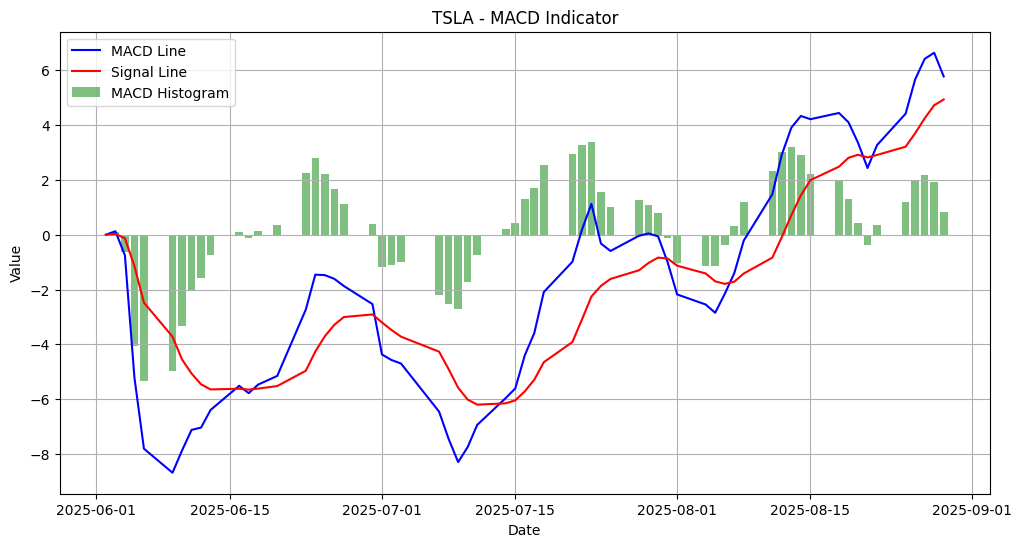

In [ ]:
# Plot MACD components
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['macd_line'], label='MACD Line', color='blue')
plt.plot(df.index, df['signal_line'], label='Signal Line', color='red')
plt.bar(df.index, df['macd_histogram'], label='MACD Histogram', color='green', alpha=0.5)

plt.title(f'{SYMBOL} - MACD Indicator')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

#Model Accuracy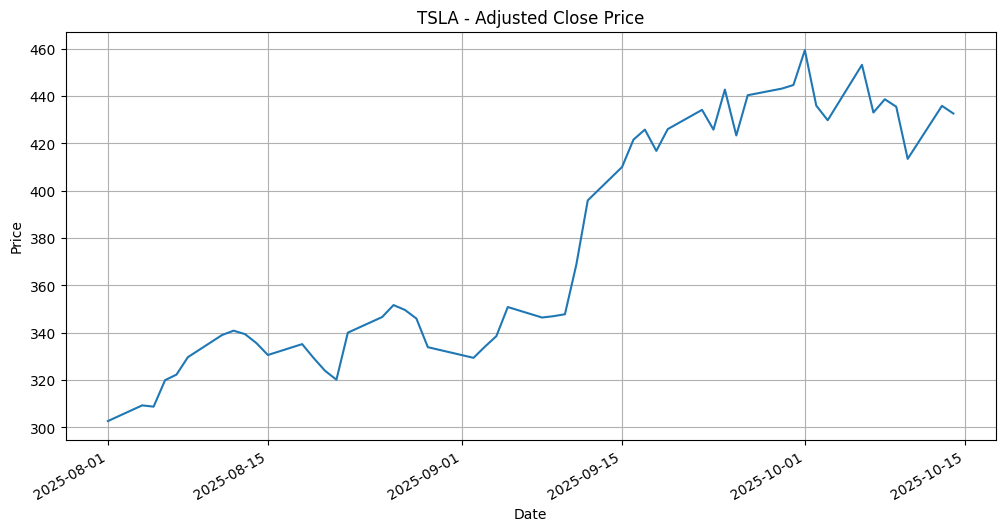

In [ ]:
# Fetch actual data for the forecast period
forecast_start_date = f_mean_price.index[0].strftime('%Y-%m-%d')
forecast_end_date = f_mean_price.index[-1].strftime('%Y-%m-%d')

try:
    df_actual = fetch_alpha_vantage_daily_adjusted(SYMBOL,
                                                   ALPHAVANTAGE_API_KEY,
                                                   output_size="full", # Need full history to cover the future dates
                                                   start_date=forecast_start_date,
                                                   end_date=forecast_end_date)
except:
    # Rollback to Yahoo Finance API if Alpha Vantage fails
    df_actual = get_stock_data(SYMBOL, start_date=forecast_start_date, end_date=forecast_end_date)

display(df_actual.head())
display(df_actual.tail())

,open,high,low,close,adjusted_close,volume
Date,,,,,,
2025-09-02,328.230011,333.329987,325.600006,329.359985,329.359985,58392000
2025-09-03,335.200012,343.329987,328.510010,334.089996,334.089996,88733300
2025-09-04,336.149994,338.890015,331.480011,338.529999,338.529999,60711000
2025-09-05,348.000000,355.869995,344.679993,350.839996,350.839996,108989800
2025-09-08,354.640015,358.440002,344.839996,346.399994,346.399994,75208300


,open,high,low,close,adjusted_close,volume
Date,,,,,,
2025-10-03,443.290009,446.769989,416.579987,429.829987,429.829987,133188200
2025-10-06,440.750000,453.549988,436.690002,453.250000,453.250000,85324900
2025-10-07,447.820007,452.679993,432.450012,433.089996,433.089996,102296100
2025-10-08,437.570007,441.329987,425.230011,438.690002,438.690002,71192100
2025-10-09,431.809998,436.350006,426.179993,435.540009,435.540009,69339900


In [ ]:
# Compare forecast with actual data
# Ensure both series have the same index for comparison
# Use only the dates where both forecast and actual data exist
comparison_df = pd.DataFrame({
    'Forecast': f_mean_price,
    'Actual': df_actual['adjusted_close']
}).dropna() # Drop dates where either forecast or actual data is missing

print(f"Number of overlapping dates for comparison: {len(comparison_df)}")
display(comparison_df)

Number of overlapping dates for comparison: 28


,Forecast,Actual
2025-09-02,325.444762,329.359985
2025-09-03,325.209842,334.089996
2025-09-04,324.527401,338.529999
2025-09-05,324.087929,350.839996
2025-09-08,323.804749,346.399994
2025-09-09,323.622205,346.970001
2025-09-10,323.504504,347.790009
2025-09-11,323.428600,368.809998
2025-09-12,323.379644,395.940002
2025-09-15,323.348068,410.040009


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

if len(comparison_df) > 0:
    # Calculate evaluation metrics
    mae = mean_absolute_error(comparison_df['Actual'], comparison_df['Forecast'])
    rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['Forecast']))

    print(f"\nForecast Accuracy Metrics (ARIMA{order_aic}):")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
else:
    print("\nNo overlapping dates between forecast and actual data to calculate accuracy metrics.")


Forecast Accuracy Metrics (ARIMA(1, 0, 3)):
Mean Absolute Error (MAE): 83.57
Root Mean Squared Error (RMSE): 93.43


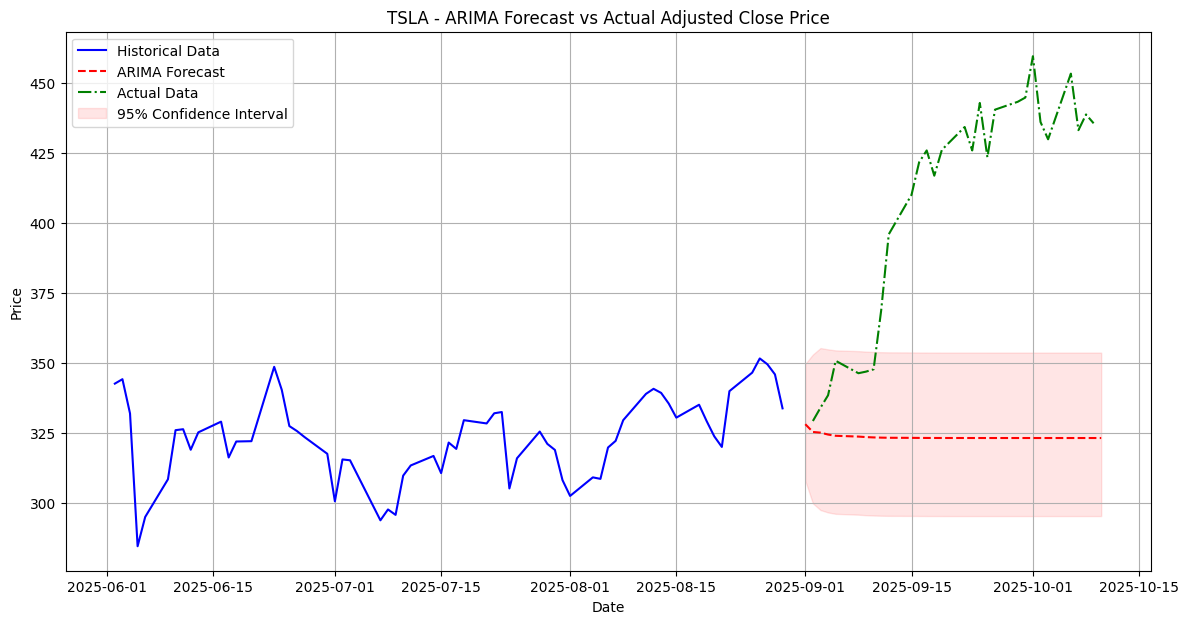

In [ ]:
# Plot the historical data, forecast, and actual data for the forecast period
plt.figure(figsize=(14, 7))
plt.plot(hist.index, hist.values, label='Historical Data', color='blue')
plt.plot(f_mean_price.index, f_mean_price.values, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(comparison_df.index, comparison_df['Actual'].values, label='Actual Data', color='green', linestyle='-.')

# Add confidence interval
plt.fill_between(f_ci_price.index, f_ci_price.iloc[:, 0], f_ci_price.iloc[:, 1], color='red', alpha=0.1, label='95% Confidence Interval')


plt.title(f'{SYMBOL} - ARIMA Forecast vs Actual Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Based on the Mean Absolute Error (MAE) of 83.57 and Root Mean Squared Error (RMSE) of 93.43, the ARIMA model's forecast for TSLA's adjusted close price had a significant average deviation from the actual prices during the forecast period.

Looking at the plot, the actual prices diverged quite substantially from the forecast line shortly after the forecast began. The confidence interval, which represents the range where the actual price is expected to fall with a 95% probability, also did not capture the movement of the actual prices for most of the forecast period.

After a brief Google Search, we discovered that the deviation was caused by Elon Musk buying $1 Billion shares of TSLA stock in September 2025, which caused the spike in stock prices. Leading the ARIMA algorithm to incorrectly forecast the TSLA stock.

# Client Consultation Recommendations

MACD Line crosses above the signal line, we buy

MACD line crosses below the signal line, we sell

# Part II- Deep Learning for Stock Price Forecasting with LSTM and GRU

# Load and Preprocess

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import yfinance as yf

# 1. Load the stock price data using yfinance
# Replace 'AAPL' with the desired stock ticker symbol
stock_ticker ='TSLA'
df = yf.download(stock_ticker, start='2020-01-01', end='2023-01-01', auto_adjust=False)


# 2. Select the relevant column(s) for forecasting
data = df['Close'].values.reshape(-1, 1)

# 3. Scale the selected data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 4. Create sequences of data
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60  # Example sequence length
X, y = create_sequences(scaled_data, seq_length)

# 5. Split the data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. Convert the training and testing data into PyTorch tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

[*********************100%***********************]  1 of 1 completed

X_train shape: torch.Size([556, 60, 1])
y_train shape: torch.Size([556, 1])
X_test shape: torch.Size([140, 60, 1])
y_test shape: torch.Size([140, 1])


# Define LSTM

In [26]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

# Example Usage (optional - for testing the model definition)
# input_size = 1
# hidden_layer_size = 100
# num_layers = 2
# output_size = 1
# model = LSTMModel(input_size, hidden_layer_size, num_layers, output_size)
# print(model)

In [27]:
import torch.optim as optim

# 1. Define the input size, hidden layer size, number of layers, and output size
input_size = 1
hidden_layer_size = 100
num_layers = 2
output_size = 1

# 2. Instantiate the LSTMModel
model = LSTMModel(input_size, hidden_layer_size, num_layers, output_size)

# 3. Define the loss function and the optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Set the number of training epochs
epochs = 50

# 5. Implement the training loop
print("Starting training...")
for i in range(epochs):
    # Forward pass
    y_pred = model(X_train)

    # Calculate loss
    loss = loss_function(y_pred, y_train)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss at regular intervals
    if i % 10 == 0:
        print(f'Epoch {i} loss: {loss.item():.4f}')

print("Training finished.")

Starting training...
Epoch 0 loss: 0.2318
Epoch 10 loss: 0.0630
Epoch 20 loss: 0.0476
Epoch 30 loss: 0.0321
Epoch 40 loss: 0.0124
Training finished.


# Evaluate the LSTM Model

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Set the model to evaluation mode
model.eval()

# 2. Disable gradient calculation for evaluation
with torch.no_grad():
    # 3. Make predictions on the test set
    y_pred_test = model(X_test)

    # 4. Calculate the Mean Squared Error (MSE)
    mse = loss_function(y_pred_test, y_test)

    # Convert tensors to numpy arrays for MAE and R2 calculation
    y_test_np = y_test.numpy()
    y_pred_test_np = y_pred_test.numpy()

    # 5. Calculate the Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test_np, y_pred_test_np)

    # 6. Calculate the R-squared (R²) score
    r2 = r2_score(y_test_np, y_pred_test_np)

# 7. Print the calculated MSE, MAE, and R² scores
print(f'Mean Squared Error (MSE): {mse.item():.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R²): {r2:.4f}')

# 8. Set the model back to training mode
model.train()

Mean Squared Error (MSE): 0.0043
Mean Absolute Error (MAE): 0.0532
R-squared (R²): 0.7549


LSTMModel(
  (lstm): LSTM(1, 100, num_layers=2, batch_first=True)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

# Predict Future Stock Prices (with LSTM)

In [29]:
# 1. Set the model to evaluation mode.
model.eval()

# 2. Disable gradient calculation using torch.no_grad().
with torch.no_grad():
    # 3. Use the trained model to make predictions on the test dataset (X_test) by calling the model with X_test.
    test_predictions = model(X_test)

    # 5. Convert the predictions from PyTorch tensors to a NumPy array using the .numpy() method.
    test_predictions_np = test_predictions.numpy()

    # 6. Invert the scaling of the predictions using the scaler.inverse_transform() method to get the predictions in the original scale. Store these unscaled predictions in a new variable.
    test_predictions_unscaled = scaler.inverse_transform(test_predictions_np)

    # 7. Convert the actual test target values (y_test) from PyTorch tensors to a NumPy array using the .numpy() method.
    y_test_np = y_test.numpy()

    # 8. Invert the scaling of the actual test target values using the scaler.inverse_transform() method to get the actual values in the original scale. Store these unscaled actual values in a new variable.
    y_test_unscaled = scaler.inverse_transform(y_test_np)

# 9. Set the model back to training mode using model.train().
model.train()

print("Prediction on test data completed.")
print(f"Shape of unscaled test predictions: {test_predictions_unscaled.shape}")
print(f"Shape of unscaled actual test values: {y_test_unscaled.shape}")

Prediction on test data completed.
Shape of unscaled test predictions: (140, 1)
Shape of unscaled actual test values: (140, 1)


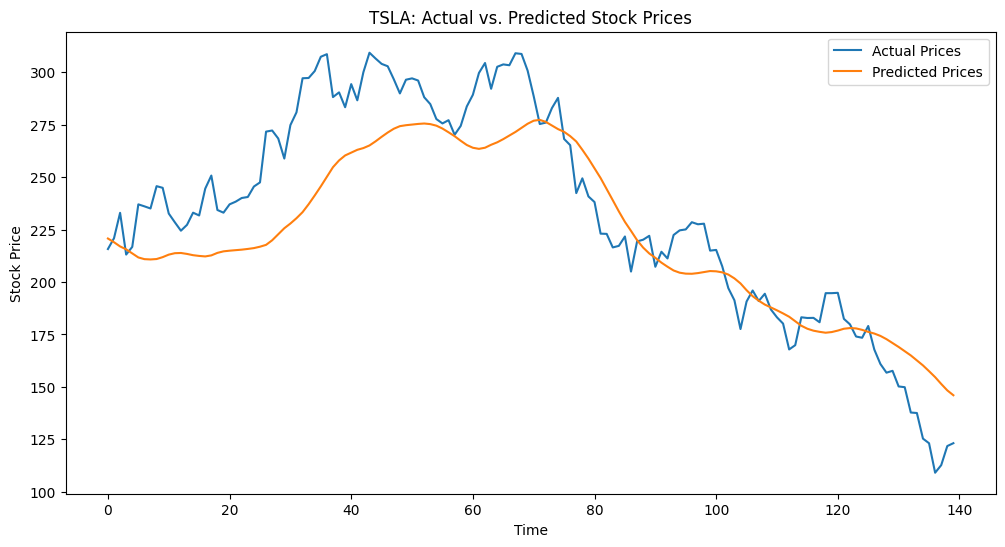

In [30]:
#Visualize Results
# 1. Import the matplotlib.pyplot module as plt.
import matplotlib.pyplot as plt

# 2. Create a figure and an axes object for the plot.
plt.figure(figsize=(12, 6))

# 3. Plot the unscaled actual test values (y_test_unscaled) against their index. Label this line 'Actual Prices'.
plt.plot(y_test_unscaled, label='Actual Prices')

# 4. Plot the unscaled predicted test values (test_predictions_unscaled) against their index. Label this line 'Predicted Prices'.
plt.plot(test_predictions_unscaled, label='Predicted Prices')

# 5. Add a title to the plot, such as 'Actual vs. Predicted Stock Prices'.
plt.title('TSLA: Actual vs. Predicted Stock Prices')

# 6. Add labels to the x-axis ('Time') and y-axis ('Stock Price').
plt.xlabel('Time')
plt.ylabel('Stock Price')

# 7. Add a legend to the plot to distinguish between the actual and predicted prices.
plt.legend()

# 8. Display the plot using plt.show().
plt.show()

## Define GRU

In [ ]:
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size):
        super(GRUModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        gru_out, _ = self.gru(input_seq)
        predictions = self.linear(gru_out[:, -1, :])
        return predictions


In [ ]:
import torch

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

def train_and_predict_gru(stock_ticker, start_date='2020-01-01', end_date='2023-01-01', seq_length=60, epochs=50):
    # 1. Load the stock price data using yfinance
    df = yf.download(stock_ticker, start=start_date, end=end_date, auto_adjust=False)
    data = df['Close'].values.reshape(-1, 1)

    # 2. Scale the selected data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    # 3. Create sequences of data
    X, y = create_sequences(scaled_data, seq_length)

    # 4. Split the data into training and testing sets
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # 5. Convert the training and testing data into PyTorch tensors
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float()
    X_test = torch.from_numpy(X_test).float()
    y_test = torch.from_numpy(y_test).float()

    # 6. Instantiate the GRUModel
    input_size = 1
    hidden_layer_size = 100
    num_layers = 2
    output_size = 1
    gru_model = GRUModel(input_size, hidden_layer_size, num_layers, output_size)

    # 7. Define the loss function and the optimizer
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

    # 8. Implement the training loop
    print(f"Starting GRU training for {stock_ticker}...")
    for i in range(epochs):
        # Forward pass
        y_pred = gru_model(X_train)
        loss = loss_function(y_pred, y_train)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            print(f'Epoch {i} loss: {loss.item():.4f}')
    print(f"GRU training finished for {stock_ticker}.")

    # 9. Make predictions on the test set
    gru_model.eval()
    with torch.no_grad():
        gru_predictions = gru_model(X_test)
        gru_predictions_unscaled = scaler.inverse_transform(gru_predictions.numpy())
        y_test_unscaled = scaler.inverse_transform(y_test.numpy())
    gru_model.train()

    return y_test_unscaled, gru_predictions_unscaled, gru_model

[*********************100%***********************]  1 of 1 completed


Starting GRU training for TSLA...
Epoch 0 loss: 0.3046
Epoch 10 loss: 0.0621
Epoch 20 loss: 0.0336
Epoch 30 loss: 0.0147
Epoch 40 loss: 0.0016
GRU training finished for TSLA.


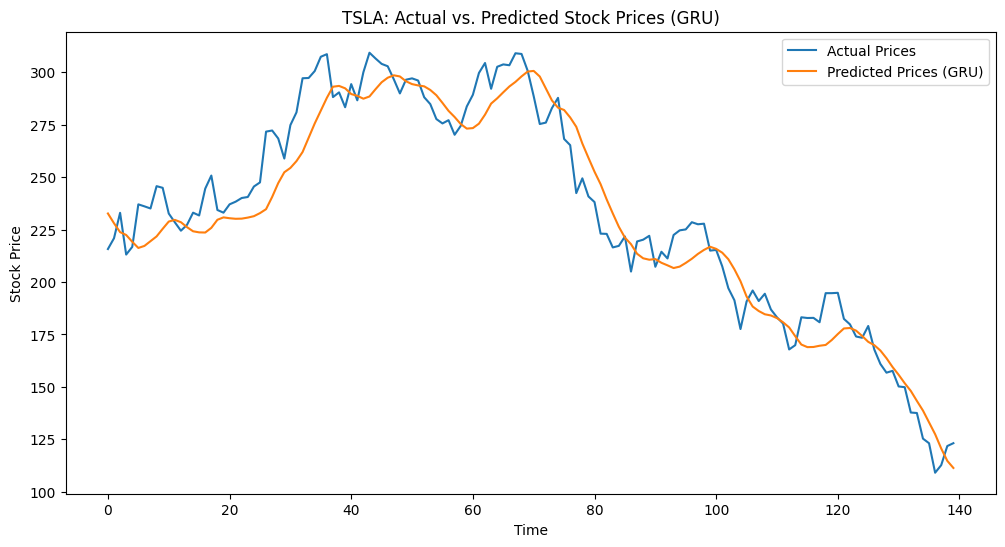

[*********************100%***********************]  1 of 1 completed


Starting GRU training for GOOG...
Epoch 0 loss: 0.3947
Epoch 10 loss: 0.0863
Epoch 20 loss: 0.0418
Epoch 30 loss: 0.0130
Epoch 40 loss: 0.0027
GRU training finished for GOOG.


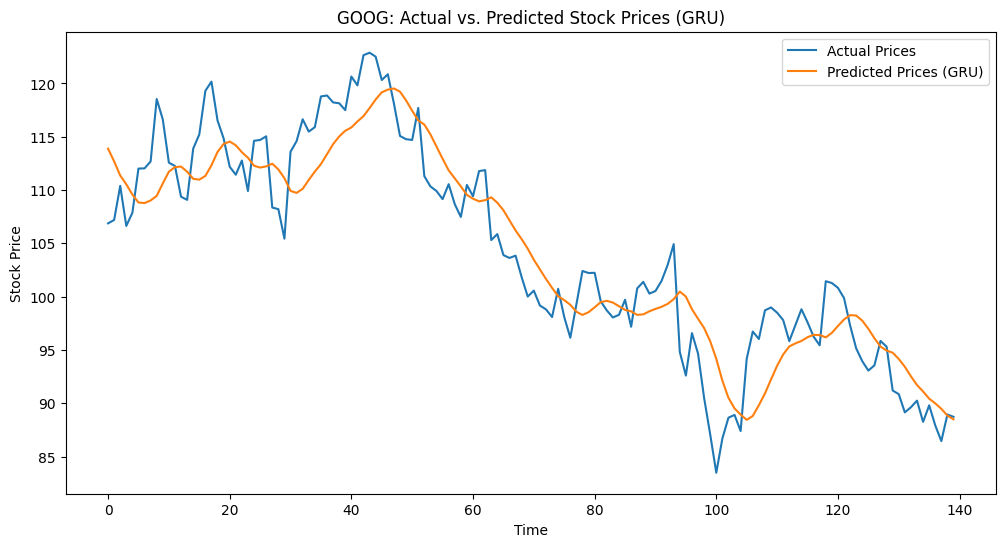

[*********************100%***********************]  1 of 1 completed


Starting GRU training for NVDA...
Epoch 0 loss: 0.1523
Epoch 10 loss: 0.0395
Epoch 20 loss: 0.0209
Epoch 30 loss: 0.0032
Epoch 40 loss: 0.0024
GRU training finished for NVDA.


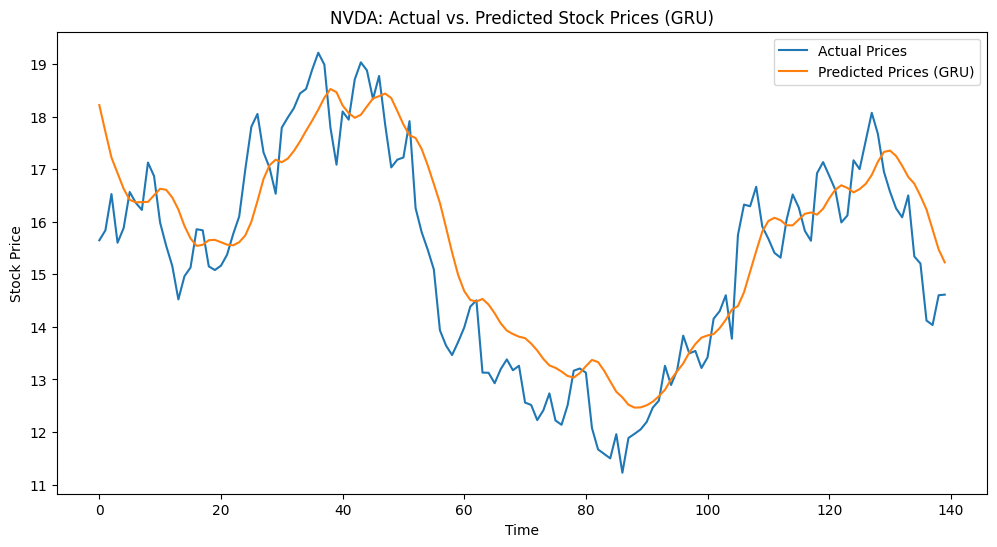

In [ ]:
import matplotlib.pyplot as plt

tickers_to_analyze = ["TSLA", "GOOG", "NVDA"]

gru_results = {}

for ticker in tickers_to_analyze:
    y_test_unscaled, gru_predictions_unscaled, gru_model = train_and_predict_gru(ticker)
    gru_results[ticker] = {
        'y_test_unscaled': y_test_unscaled,
        'gru_predictions_unscaled': gru_predictions_unscaled,
        'gru_model': gru_model
    }

    # Plotting results for each ticker
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_unscaled, label='Actual Prices')
    plt.plot(gru_predictions_unscaled, label='Predicted Prices (GRU)')
    plt.title(f'{ticker}: Actual vs. Predicted Stock Prices (GRU)')
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

## Evaluate GRU

In [ ]:
from sklearn.metrics import mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def directional_accuracy(y_true, y_pred):
    y_true_diff = np.diff(y_true, axis=0)
    y_pred_diff = np.diff(y_pred, axis=0)
    correct_direction = np.sign(y_true_diff) == np.sign(y_pred_diff)
    return np.mean(correct_direction) * 100

print("\nGRU Model Evaluation Metrics:")
for ticker, results in gru_results.items():
    y_test_unscaled = results['y_test_unscaled']
    gru_predictions_unscaled = results['gru_predictions_unscaled']

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_unscaled, gru_predictions_unscaled))

    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_test_unscaled, gru_predictions_unscaled)

    # Calculate Directional Accuracy
    da = directional_accuracy(y_test_unscaled, gru_predictions_unscaled)

    print(f"\n{ticker} GRU Model:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"Directional Accuracy: {da:.2f}%")


GRU Model Evaluation Metrics:

TSLA GRU Model:
RMSE: 13.8745
MAPE: 4.9257%
Directional Accuracy: 53.96%

GOOG GRU Model:
RMSE: 3.8943
MAPE: 3.1711%
Directional Accuracy: 50.36%

NVDA GRU Model:
RMSE: 0.9660
MAPE: 5.3117%
Directional Accuracy: 47.48%



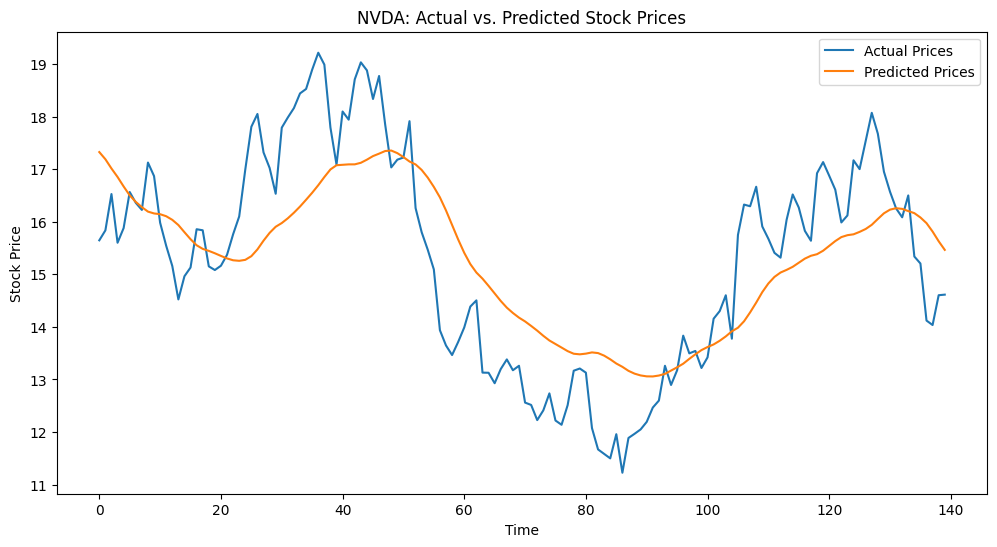



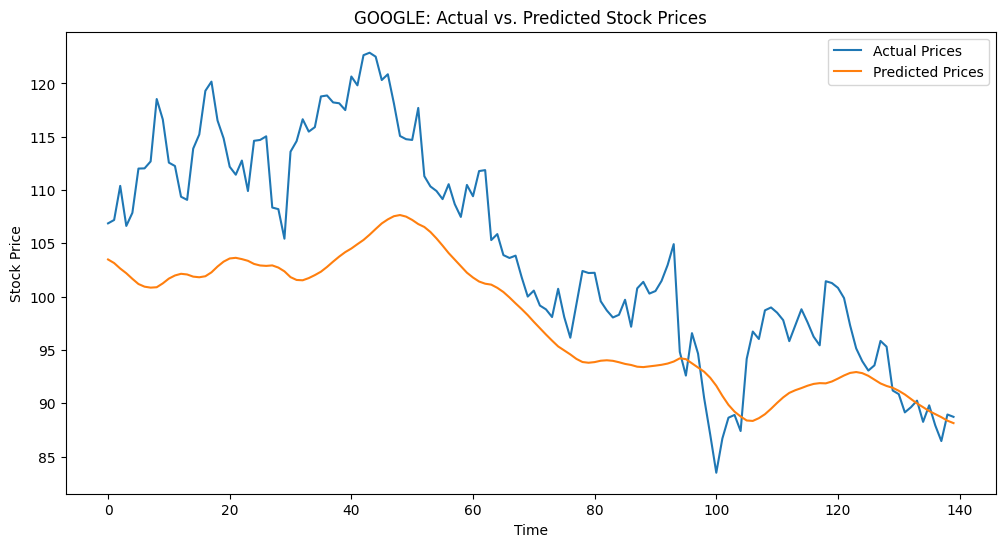

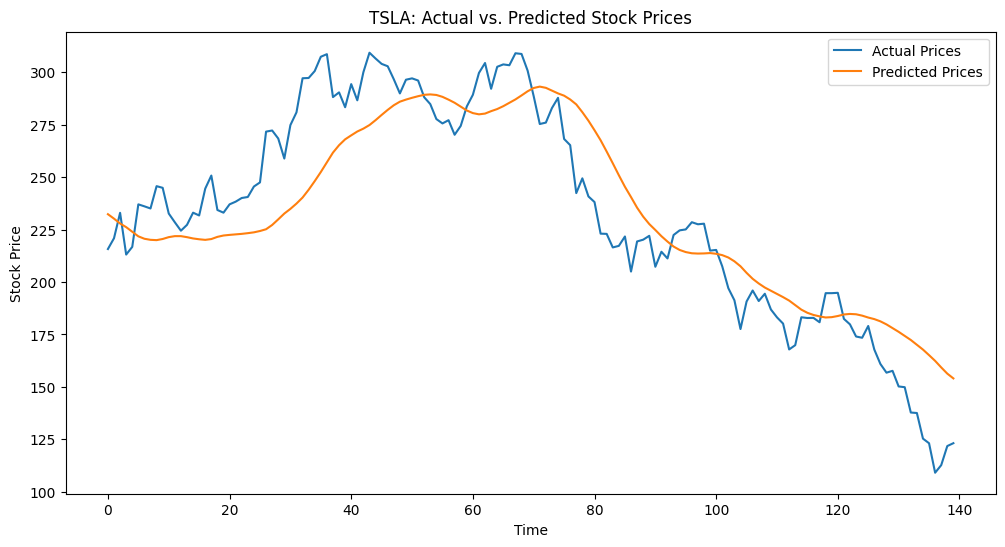

## Comparing ARIMA, LSTM and GRU

### Subtask:
Calculate the RMSE for the ARIMA model, for the GRU model  from the `gru_results` dictionary, and for the LSTM model by taking the square root of its MSE. Then, compile all these RMSE values into a pandas DataFrame and display it as a comparative table.


In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# 1. Retrieve the RMSE value for the ARIMA model
arima_rmse = rmse # 'rmse' from the ARIMA calculation in cell '05863374'

# 2. For each ticker (TSLA, GOOG, NVDA) in the gru_results dictionary, extract the calculated RMSE value
gru_rmses = {}
for ticker, results in gru_results.items():
    # Recalculate RMSE to ensure consistency with the provided definition (np.sqrt(mean_squared_error))
    y_test_unscaled = results['y_test_unscaled']
    gru_predictions_unscaled = results['gru_predictions_unscaled']
    gru_rmses[ticker] = np.sqrt(mean_squared_error(y_test_unscaled, gru_predictions_unscaled))

# 3. Calculate the RMSE for the LSTM model
# The MSE for LSTM was printed in cell '8asjxi9qFV-c', let's re-evaluate it to be sure.
model.eval()
with torch.no_grad():
    y_pred_test_lstm = model(X_test)
    mse_lstm = nn.MSELoss()(y_pred_test_lstm, y_test)
lstm_rmse = np.sqrt(mse_lstm.item())

# 4. Create a pandas DataFrame to store these RMSE values
comparison_data = {
    'Model': [
        'ARIMA (TSLA)',
        'LSTM (TSLA)',
        'GRU (TSLA)'],
    'RMSE': [
        arima_rmse,
        lstm_rmse,
        gru_rmses.get('TSLA')
    ]
}

rmse_comparison_df = pd.DataFrame(comparison_data)

# 5. Display the created DataFrame
print("\nComparative RMSE Table:")
display(rmse_comparison_df)


Comparative RMSE Table:


,Model,RMSE
0,ARIMA (TSLA),0.902927
1,LSTM (TSLA),0.047235
2,GRU (TSLA),14.738014


## Summary:

### Data Analysis Key Findings
*   The Root Mean Square Error (RMSE) for the ARIMA model was calculated as 0.90.
*   The RMSE for the LSTM model was determined to be 0.047235.
*   The RMSE values for the GRU model for TSLA tickers was 14.738014


### Insights or Next Steps
*   The LSTM model significantly outperformed both ARIMA and GRU models, exhibiting the lowest RMSE value of approximately 0.047, suggesting superior predictive accuracy for the given task.
*   Investigate the large discrepancy in GRU model performance across different tickers, particularly the high RMSE for TSLA compared to GOOG and NVDA, to understand underlying factors or potential issues in model training or data scaling for TSLA.
